# Linear Regression
## First part :
visualize the new dataset and add noise on the inputs and outputs, plot ground truth.

(Step 0 of the assignement)

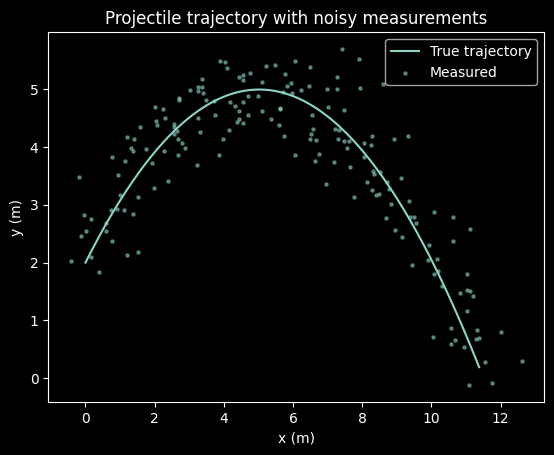

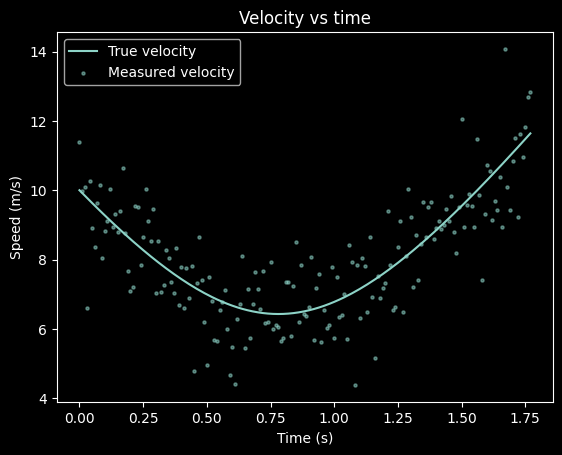

In [3]:
# Version Emil 24/04

import numpy as np
import matplotlib.pyplot as plt

# Constants
g = 9.81  # m/s^2
v0 = 10.0  # m/s
theta = np.deg2rad(50)  # radians
x0, y0 = 0.0, 2.0

dt = 0.01

# Initial velocities
vx0 = v0 * np.cos(theta)
vy0 = v0 * np.sin(theta)

# Storage
t_vals = [0]
x_true = [x0]
y_true = [y0]
v_true = [v0]

x_meas = []
y_meas = []
v_meas = []

t = 0

# Simulation loop
while True:
    t += dt

    # True state
    x = x0 + vx0 * t
    y = y0 + vy0 * t - 0.5 * g * t**2
    vx = vx0
    vy = vy0 - g * t
    v = np.sqrt(vx**2 + vy**2)

    if y <= 0:
        break

    # Store true values
    t_vals.append(t)
    x_true.append(x)
    y_true.append(y)
    v_true.append(v)

    # Noisy measurements
    x_m = np.random.normal(x, 0.5)
    y_m = np.random.normal(y, 0.5)
    v_m = np.random.normal(v, 1.0)

    x_meas.append(x_m)
    y_meas.append(y_m)
    v_meas.append(v_m)

# Convert to arrays
t_vals = np.array(t_vals[:-1])  # align sizes
x_true = np.array(x_true[:-1])
y_true = np.array(y_true[:-1])
v_true = np.array(v_true[:-1])

x_meas = np.array(x_meas)
y_meas = np.array(y_meas)
v_meas = np.array(v_meas)

# Plot trajectory
plt.figure()
plt.plot(x_true, y_true, label="True trajectory")
plt.scatter(x_meas, y_meas, s=5, alpha=0.5, label="Measured")
plt.xlabel("x (m)")
plt.ylabel("y (m)")
plt.legend()
plt.title("Projectile trajectory with noisy measurements")
plt.show()

# Plot velocity
plt.figure()
plt.plot(t_vals, v_true, label="True velocity")
plt.scatter(t_vals, v_meas, s=5, alpha=0.5, label="Measured velocity")
plt.xlabel("Time (s)")
plt.ylabel("Speed (m/s)")
plt.legend()
plt.title("Velocity vs time")
plt.show()

In [4]:
!from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression, Lasso, LassoCV, Ridge, RidgeCV
from sklearn.metrics import r2_score, mean_squared_error
from ipywidgets import interact, FloatLogSlider

import numpy as np
import matplotlib.pyplot as plt

x_train, x_test, y_train, y_test = train_test_split(x_meas.reshape(-1,1), y_meas.reshape(-1,1), test_size=0.2, random_state=1)


1) Build a polynomial regression using the OLS method to predict the $y$ position of the projectile using the noisy $x$ measurements as input. The dataset containing $x$ and $y$ has to be divided into a training part and a test part. This can be done using the __train_test_split__ function in the __sklearn__ package. Usually, the test size is set to 20 % of the entire dataset.\
To perform the regression, you have to first build the matrix $\mathbf{A}$ in Eq. 3. This can be done by using the __PolynomialFeatures__ function, where you will set the degree of the polynomial to 2. After you have built the matrix $\mathbf{A}$, you will have to scale both $\mathbf{A}$ and the vector of noisy measurements $y$ using the function __StandardScaler__.
The actual regression is done using the __LinearRegression__ function, in which the parameters to input are the scaled matrix $\mathbf{A_0}$ and the vector $\mathbf{b_0}$, which contains the noisy measurements of the scaled $y$ position.\
Once the model is trained, you can judge the quality of the model by using the __score__ attribute of the model, in which you have to input the testing data. Do not forget to scale the testing data as well.



R^2 score on test set: 0.7543


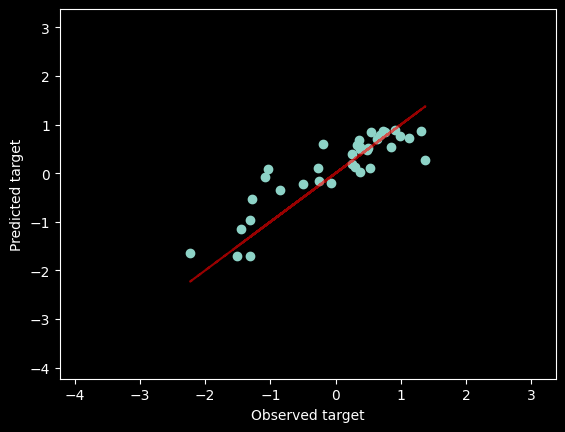

<Figure size 640x480 with 0 Axes>

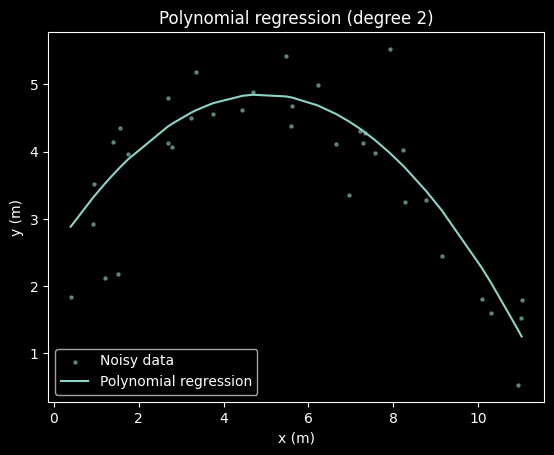

In [5]:
# Version Emil 24/04
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

x_train, x_test, y_train, y_test = train_test_split(x_meas.reshape(-1,1), y_meas.reshape(-1,1), test_size=0.2, random_state=1)
poly = PolynomialFeatures(2)
A_train = poly.fit_transform(x_train)
A_test = poly.transform(x_test)

scaler_A = StandardScaler()
scaler_y = StandardScaler()

A0_train = scaler_A.fit_transform(A_train)
A0_test = scaler_A.transform(A_test)

y0_train = scaler_y.fit_transform(y_train)
y0_test = scaler_y.transform(y_test)

model = LinearRegression()
OLS_reg = model.fit(A0_train, y0_train)

y_pred_OLS = OLS_reg.predict(A0_test)

score = model.score(A0_test, y0_test)

print(f"R^2 score on test set: {score:.4f}")

plt.figure()
plt.scatter(y0_test, y_pred_OLS)
plt.plot(y0_test, y0_test, c='r', alpha=0.6, ls='--')
plt.xlim(y0_test.min()-2, y0_test.max()+2)
plt.ylim(y0_test.min()-2, y0_test.max()+2)
plt.xlabel('Observed target')
plt.ylabel('Predicted target')
plt.show()


plt.figure()

y_pred = scaler_y.inverse_transform(y_pred_OLS)

sort_idx = np.argsort(x_test.flatten())

# Apply sorting
x_test_sorted = x_test.flatten()[sort_idx]
y_test_sorted = y_test.flatten()[sort_idx]
y_pred_sorted = y_pred.flatten()[sort_idx]

# Plot
plt.figure()
plt.scatter(x_test, y_test, s=5, alpha=0.5, label="Noisy data")
plt.plot(x_test_sorted, y_pred_sorted, label="Polynomial regression")
plt.xlabel("x (m)")
plt.ylabel("y (m)")
plt.legend()
plt.title("Polynomial regression (degree 2)")
plt.show()

PART 1 — OLS Degree 2
R²: 0.754308297351451
MSE: 0.3810160022434779


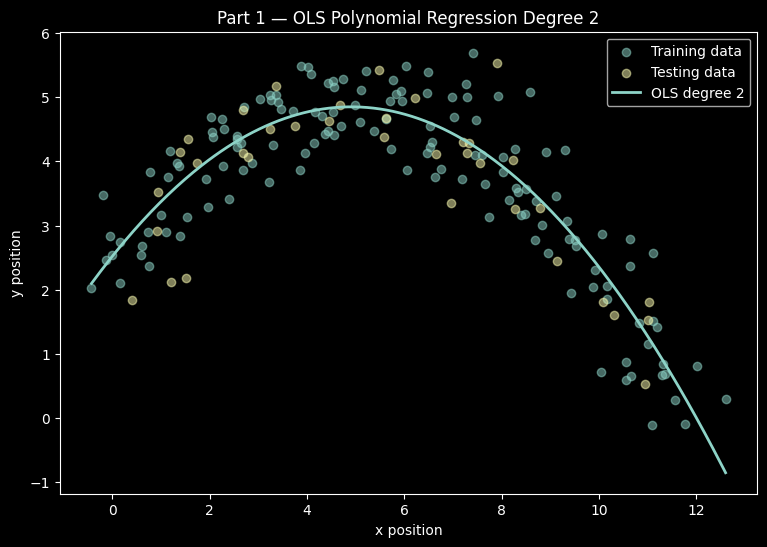

In [6]:
# VERSION SELIM



from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np
import matplotlib.pyplot as plt

poly2 = PolynomialFeatures(degree=2)

A_train_2 = poly2.fit_transform(x_train)
A_test_2 = poly2.transform(x_test)

scaler_A2 = StandardScaler()
A_train_2_scaled = scaler_A2.fit_transform(A_train_2)
A_test_2_scaled = scaler_A2.transform(A_test_2)

scaler_y2 = StandardScaler()
y_train_2_scaled = scaler_y2.fit_transform(y_train.reshape(-1, 1)).ravel()

OLS_2 = LinearRegression()
OLS_2.fit(A_train_2_scaled, y_train_2_scaled)

y_pred_OLS2_scaled = OLS_2.predict(A_test_2_scaled)

y_pred_OLS2 = scaler_y2.inverse_transform(
    y_pred_OLS2_scaled.reshape(-1, 1)
).ravel()

r2_OLS2 = r2_score(y_test, y_pred_OLS2)
mse_OLS2 = mean_squared_error(y_test, y_pred_OLS2)

print("PART 1 — OLS Degree 2")
print("R²:", r2_OLS2)
print("MSE:", mse_OLS2)

x_plot = np.linspace(min(x_train), max(x_train), 300).reshape(-1, 1)

A_plot_2 = poly2.transform(x_plot)
A_plot_2_scaled = scaler_A2.transform(A_plot_2)

y_plot_OLS2_scaled = OLS_2.predict(A_plot_2_scaled)
y_plot_OLS2 = scaler_y2.inverse_transform(
    y_plot_OLS2_scaled.reshape(-1, 1)
).ravel()

plt.figure(figsize=(9, 6))
plt.scatter(x_train, y_train, alpha=0.5, label="Training data")
plt.scatter(x_test, y_test, alpha=0.5, label="Testing data")
plt.plot(x_plot, y_plot_OLS2, label="OLS degree 2", linewidth=2)

plt.xlabel("x position")
plt.ylabel("y position")
plt.title("Part 1 — OLS Polynomial Regression Degree 2")
plt.legend()
plt.show()

2) Build the same OLS regression model using a 20 degree polynomial. Then compare the obtained prediction with the Lasso regression model. You can use the __Lasso__ model from the __sklearn__ package. Try different values of the __alpha__ parameter.


R^2 score on test set: 0.7717


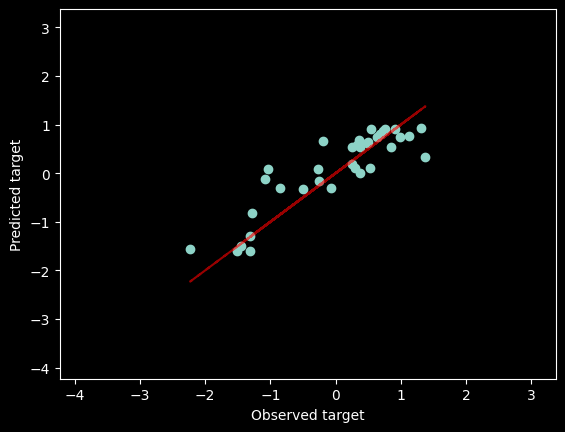

<Figure size 640x480 with 0 Axes>

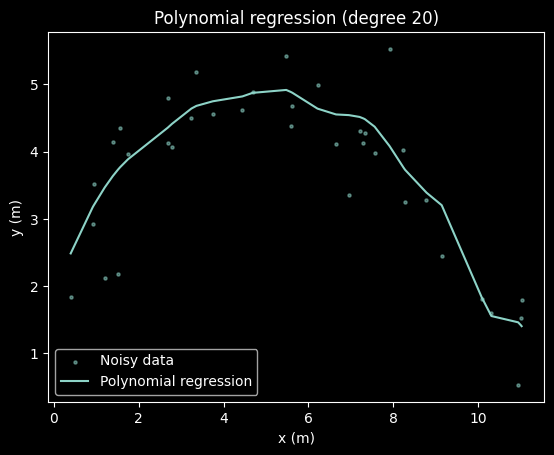

In [7]:
# Version Emil 24/04
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

x_train, x_test, y_train, y_test = train_test_split(x_meas.reshape(-1,1), y_meas.reshape(-1,1), test_size=0.2, random_state=1)
poly = PolynomialFeatures(20) # New polynomial degree
A_train = poly.fit_transform(x_train)
A_test = poly.transform(x_test)

scaler_A = StandardScaler()
scaler_y = StandardScaler()

A0_train = scaler_A.fit_transform(A_train)
A0_test = scaler_A.transform(A_test)

y0_train = scaler_y.fit_transform(y_train)
y0_test = scaler_y.transform(y_test)

model = LinearRegression()
OLS_reg_2 = model.fit(A0_train, y0_train)

y_pred_OLS2 = OLS_reg_2.predict(A0_test)

score = model.score(A0_test, y0_test)

print(f"R^2 score on test set: {score:.4f}")

plt.figure()
plt.scatter(y0_test, y_pred_OLS2)
plt.plot(y0_test, y0_test, c='r', alpha=0.6, ls='--')
plt.xlim(y0_test.min()-2, y0_test.max()+2)
plt.ylim(y0_test.min()-2, y0_test.max()+2)
plt.xlabel('Observed target')
plt.ylabel('Predicted target')
plt.show()


plt.figure()

y_pred = scaler_y.inverse_transform(y_pred_OLS2)

sort_idx = np.argsort(x_test.flatten())

# Apply sorting
x_test_sorted = x_test.flatten()[sort_idx]
y_test_sorted = y_test.flatten()[sort_idx]
y_pred_sorted = y_pred.flatten()[sort_idx]

# Plot
plt.figure()
plt.scatter(x_test, y_test, s=5, alpha=0.5, label="Noisy data")
plt.plot(x_test_sorted, y_pred_sorted, label="Polynomial regression")
plt.xlabel("x (m)")
plt.ylabel("y (m)")
plt.legend()
plt.title("Polynomial regression (degree 20)")
plt.show()

# We see that there is a clear overfitting of the point cloud.

In [8]:
from sklearn.linear_model import Lasso
from sklearn.metrics import r2_score, mean_squared_error, root_mean_squared_error
Lasso_reg = Lasso(alpha=0.1).fit(A0_train, y0_train)
y_pred_lasso = Lasso_reg.predict(A0_test)

print('LS coefficients: ')
print(np.round(OLS_reg.coef_, 3))

print('Lasso coefficients: ')
print(np.round(Lasso_reg.coef_, 3))

r2_ols = r2_score(y0_test, y_pred_OLS)
r2_lasso = r2_score(y0_test, y_pred_lasso)

print(f'R2 for OLS is: {r2_ols:.2f}')
print(f'R2 for Lasso is: {r2_lasso:.2f}')

LS coefficients: 
[[ 0.     2.365 -2.935]]
Lasso coefficients: 
[ 0.     0.    -0.    -0.    -0.    -0.688 -0.    -0.    -0.    -0.
 -0.    -0.    -0.    -0.    -0.    -0.    -0.    -0.     0.     0.
  0.   ]
R2 for OLS is: 0.75
R2 for Lasso is: 0.48


PART 2 — OLS Degree 20
R²: 0.7716898149690472
MSE: 0.3540609350426352

Lasso alpha = 0.001
R²: 0.7554421320856481
MSE: 0.3792576637527127
Non-zero coefficients: 6

Lasso alpha = 0.01
R²: 0.7307936311536919
MSE: 0.4174822891069628
Non-zero coefficients: 5

Lasso alpha = 0.1
R²: 0.4754657847270204
MSE: 0.8134419176097105
Non-zero coefficients: 1

Lasso alpha = 1
R²: -0.00044098405287074094
MSE: 1.5514729236486366
Non-zero coefficients: 0


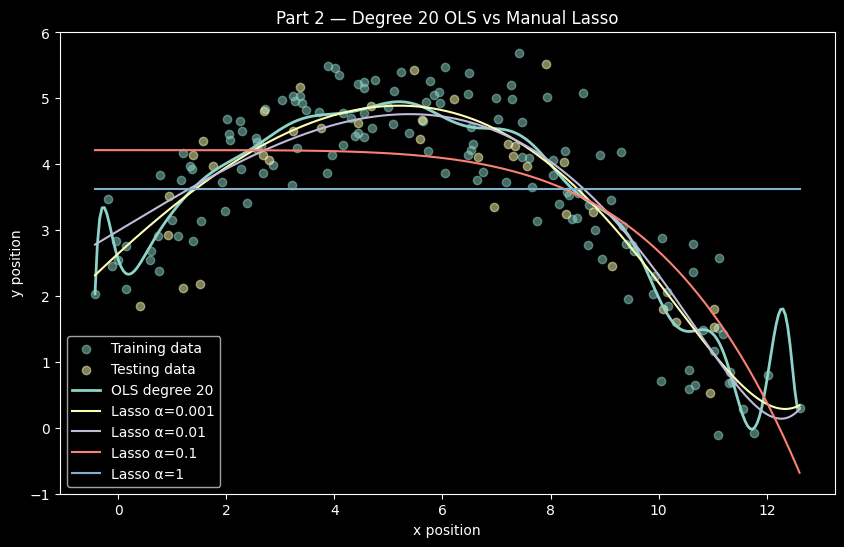

In [9]:
# VERSION SELIM





from sklearn.linear_model import Lasso

poly20 = PolynomialFeatures(degree=20)

A_train_20 = poly20.fit_transform(x_train)
A_test_20 = poly20.transform(x_test)

scaler_A20 = StandardScaler()
A_train_20_scaled = scaler_A20.fit_transform(A_train_20)
A_test_20_scaled = scaler_A20.transform(A_test_20)

scaler_y20 = StandardScaler()
y_train_20_scaled = scaler_y20.fit_transform(y_train.reshape(-1, 1)).ravel()

OLS_20 = LinearRegression()
OLS_20.fit(A_train_20_scaled, y_train_20_scaled)

y_pred_OLS20_scaled = OLS_20.predict(A_test_20_scaled)

y_pred_OLS20 = scaler_y20.inverse_transform(
    y_pred_OLS20_scaled.reshape(-1, 1)
).ravel()

r2_OLS20 = r2_score(y_test, y_pred_OLS20)
mse_OLS20 = mean_squared_error(y_test, y_pred_OLS20)

print("PART 2 — OLS Degree 20")
print("R²:", r2_OLS20)
print("MSE:", mse_OLS20)

alphas = [0.001, 0.01, 0.1, 1]

lasso_models = {}
lasso_results = {}

for alpha in alphas:
    lasso = Lasso(alpha=alpha, max_iter=100000)
    lasso.fit(A_train_20_scaled, y_train_20_scaled)

    y_pred_lasso_scaled = lasso.predict(A_test_20_scaled)

    y_pred_lasso = scaler_y20.inverse_transform(
        y_pred_lasso_scaled.reshape(-1, 1)
    ).ravel()

    r2 = r2_score(y_test, y_pred_lasso)
    mse = mean_squared_error(y_test, y_pred_lasso)
    non_zero = np.sum(lasso.coef_ != 0)

    lasso_models[alpha] = lasso
    lasso_results[alpha] = [r2, mse, non_zero]

    print(f"\nLasso alpha = {alpha}")
    print("R²:", r2)
    print("MSE:", mse)
    print("Non-zero coefficients:", non_zero)

A_plot_20 = poly20.transform(x_plot)
A_plot_20_scaled = scaler_A20.transform(A_plot_20)

y_plot_OLS20_scaled = OLS_20.predict(A_plot_20_scaled)

y_plot_OLS20 = scaler_y20.inverse_transform(
    y_plot_OLS20_scaled.reshape(-1, 1)
).ravel()

plt.figure(figsize=(10, 6))
plt.scatter(x_train, y_train, alpha=0.5, label="Training data")
plt.scatter(x_test, y_test, alpha=0.5, label="Testing data")

plt.plot(x_plot, y_plot_OLS20, label="OLS degree 20", linewidth=2)

for alpha, model in lasso_models.items():
    y_plot_lasso_scaled = model.predict(A_plot_20_scaled)

    y_plot_lasso = scaler_y20.inverse_transform(
        y_plot_lasso_scaled.reshape(-1, 1)
    ).ravel()

    plt.plot(x_plot, y_plot_lasso, label=f"Lasso α={alpha}")

plt.xlabel("x position")
plt.ylabel("y position")
plt.title("Part 2 — Degree 20 OLS vs Manual Lasso")
plt.legend()
plt.show()

3) The optimal value of the $\alpha$ parameter can be inferred from the data using a process called cross-validation. The function __LassoCV__ uses an iterative cross-validating algorithm to select the best value of $\alpha$. Compare the results obtained with the one obtained by manually selecting $\alpha$.


R2 for LassoCV is: 0.76


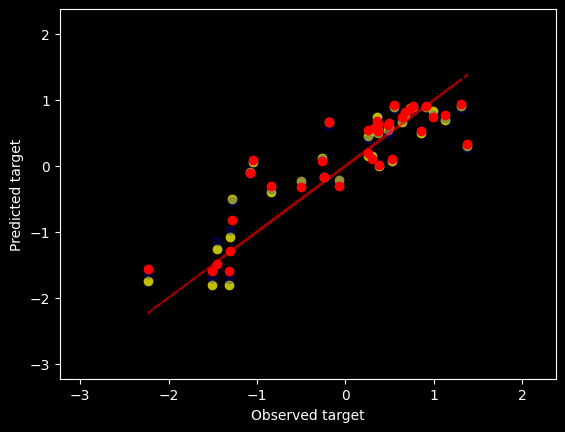

alpha :  0.0007875827813631869


In [10]:
# Version Emil 24/04
from sklearn.linear_model import LassoCV
#print(y0_train)
#print(y0_train.flatten())
LassoCV_reg = LassoCV(cv=5, random_state=42, tol=0.01).fit(A0_train, y0_train.flatten()) # Bizarre qu'il faille mettre une tol aussi basse...
y_pred_lassoCV = LassoCV_reg.predict(A0_test)

r2_lassoCV = r2_score(y0_test, y_pred_lassoCV)
print(f'R2 for LassoCV is: {r2_lassoCV:.2f}')

plt.scatter(y0_test, y_pred_lassoCV, c='y', alpha = 1)
plt.scatter(y0_test, y_pred_OLS,c='b', alpha=0.2) # 2 degree polynomial
plt.scatter(y0_test, y_pred_OLS2,c='r') # 20 degree polynomial
plt.plot(y0_test, y0_test, c='r', alpha=0.6, ls='--')
plt.xlim(y0_test.min()-1, y0_test.max()+1)
plt.ylim(y0_test.min()-1, y0_test.max()+1)
plt.xlabel('Observed target')
plt.ylabel('Predicted target')
plt.show()
# We see that there is a clear inprovment than with the OLS with overfitting.
# When OLS is choosed with degree = 2, no overfitting, exact matching with the lasso.

# Lasso with d=20 works also as well as the orginial d=2 with ols ( perfect stacking )

print("alpha : ",LassoCV_reg.alpha_)

PART 3 — LassoCV Results
Best alpha selected by LassoCV: 0.0011497569953977356
R²: 0.754954608923424
MSE: 0.3800137093345101
Non-zero coefficients: 5

Comparison with manual Lasso models from Part 2:
Manual alpha = 0.001 → R² = 0.7554, MSE = 0.3793, Non-zero coefficients = 6
Manual alpha = 0.01 → R² = 0.7308, MSE = 0.4175, Non-zero coefficients = 5
Manual alpha = 0.1 → R² = 0.4755, MSE = 0.8134, Non-zero coefficients = 1
Manual alpha = 1 → R² = -0.0004, MSE = 1.5515, Non-zero coefficients = 0


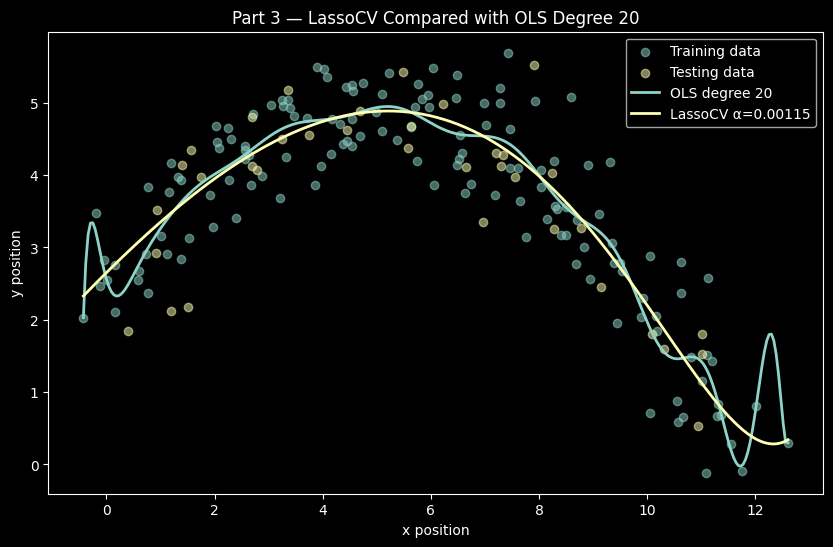

In [11]:
# VERSION Selim



from sklearn.linear_model import LassoCV
from ipywidgets import interact, FloatLogSlider

alpha_grid = np.logspace(-4, 1, 100)

lasso_cv = LassoCV(
    alphas=alpha_grid,
    cv=5,
    max_iter=100000,
    random_state=42
)

lasso_cv.fit(A_train_20_scaled, y_train_20_scaled)

y_pred_lassoCV_scaled = lasso_cv.predict(A_test_20_scaled)

y_pred_lassoCV = scaler_y20.inverse_transform(
    y_pred_lassoCV_scaled.reshape(-1, 1)
).ravel()

r2_lassoCV = r2_score(y_test, y_pred_lassoCV)
mse_lassoCV = mean_squared_error(y_test, y_pred_lassoCV)
non_zero_lassoCV = np.sum(lasso_cv.coef_ != 0)

print("PART 3 — LassoCV Results")
print("Best alpha selected by LassoCV:", lasso_cv.alpha_)
print("R²:", r2_lassoCV)
print("MSE:", mse_lassoCV)
print("Non-zero coefficients:", non_zero_lassoCV)

print("\nComparison with manual Lasso models from Part 2:")

for alpha, values in lasso_results.items():
    print(
        f"Manual alpha = {alpha} "
        f"→ R² = {values[0]:.4f}, "
        f"MSE = {values[1]:.4f}, "
        f"Non-zero coefficients = {values[2]}"
    )

y_plot_lassoCV_scaled = lasso_cv.predict(A_plot_20_scaled)

y_plot_lassoCV = scaler_y20.inverse_transform(
    y_plot_lassoCV_scaled.reshape(-1, 1)
).ravel()

plt.figure(figsize=(10, 6))
plt.scatter(x_train, y_train, alpha=0.5, label="Training data")
plt.scatter(x_test, y_test, alpha=0.5, label="Testing data")

plt.plot(x_plot, y_plot_OLS20, label="OLS degree 20", linewidth=2)
plt.plot(
    x_plot,
    y_plot_lassoCV,
    label=f"LassoCV α={lasso_cv.alpha_:.5f}",
    linewidth=2
)

plt.xlabel("x position")
plt.ylabel("y position")
plt.title("Part 3 — LassoCV Compared with OLS Degree 20")
plt.legend()
plt.show()



4) Repeat the same process by applying the __Ridge__ and __RidgeCV__ regressions and compare the results to the OLS results.



Ridge alpha = 0.001
R²: 0.7604648755140022
MSE: 0.3714684482410123

Ridge alpha = 0.01
R²: 0.7584434511245838
MSE: 0.3746032510503501

Ridge alpha = 0.1
R²: 0.7549189795413158
MSE: 0.3800689629901563

Ridge alpha = 1
R²: 0.7355553737440936
MSE: 0.4100978308369062

Ridge alpha = 10
R²: 0.6556824263005743
MSE: 0.5339639231561328

Ridge alpha = 100
R²: 0.5061202680283139
MSE: 0.7659032805601484

RidgeCV Results
Best alpha selected by RidgeCV: 0.10974987654930557
R²: 0.7546097155154889
MSE: 0.3805485662550938


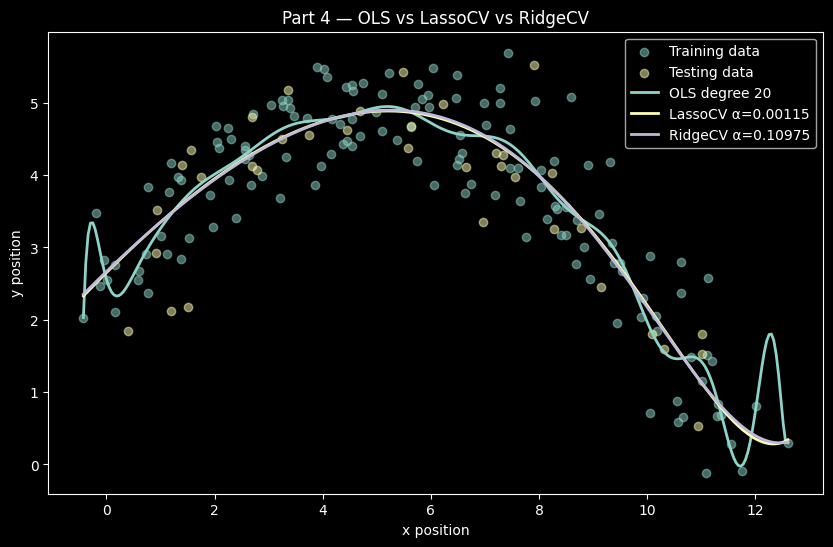

In [12]:
# VERSION Selim

from sklearn.linear_model import Ridge, RidgeCV

ridge_alphas = [0.001, 0.01, 0.1, 1, 10, 100]

ridge_models = {}
ridge_results = {}

for alpha in ridge_alphas:
    ridge = Ridge(alpha=alpha)
    ridge.fit(A_train_20_scaled, y_train_20_scaled)

    y_pred_ridge_scaled = ridge.predict(A_test_20_scaled)

    y_pred_ridge = scaler_y20.inverse_transform(
        y_pred_ridge_scaled.reshape(-1, 1)
    ).ravel()

    r2 = r2_score(y_test, y_pred_ridge)
    mse = mean_squared_error(y_test, y_pred_ridge)

    ridge_models[alpha] = ridge
    ridge_results[alpha] = [r2, mse]

    print(f"\nRidge alpha = {alpha}")
    print("R²:", r2)
    print("MSE:", mse)

ridge_cv = RidgeCV(alphas=np.logspace(-4, 3, 100), cv=5)

ridge_cv.fit(A_train_20_scaled, y_train_20_scaled)

y_pred_ridgeCV_scaled = ridge_cv.predict(A_test_20_scaled)

y_pred_ridgeCV = scaler_y20.inverse_transform(
    y_pred_ridgeCV_scaled.reshape(-1, 1)
).ravel()

r2_ridgeCV = r2_score(y_test, y_pred_ridgeCV)
mse_ridgeCV = mean_squared_error(y_test, y_pred_ridgeCV)

print("\nRidgeCV Results")
print("Best alpha selected by RidgeCV:", ridge_cv.alpha_)
print("R²:", r2_ridgeCV)
print("MSE:", mse_ridgeCV)

y_plot_ridgeCV_scaled = ridge_cv.predict(A_plot_20_scaled)

y_plot_ridgeCV = scaler_y20.inverse_transform(
    y_plot_ridgeCV_scaled.reshape(-1, 1)
).ravel()

plt.figure(figsize=(10, 6))
plt.scatter(x_train, y_train, alpha=0.5, label="Training data")
plt.scatter(x_test, y_test, alpha=0.5, label="Testing data")

plt.plot(x_plot, y_plot_OLS20, label="OLS degree 20", linewidth=2)
plt.plot(x_plot, y_plot_lassoCV, label=f"LassoCV α={lasso_cv.alpha_:.5f}", linewidth=2)
plt.plot(x_plot, y_plot_ridgeCV, label=f"RidgeCV α={ridge_cv.alpha_:.5f}", linewidth=2)

plt.xlabel("x position")
plt.ylabel("y position")
plt.title("Part 4 — OLS vs LassoCV vs RidgeCV")
plt.legend()
plt.show()
plt.show()

5.Finally, compare the Lasso and Ridge regression results in extrapolation. To do that, you can predict y by using as input a vector x which is 30% bigger than the one used for training.

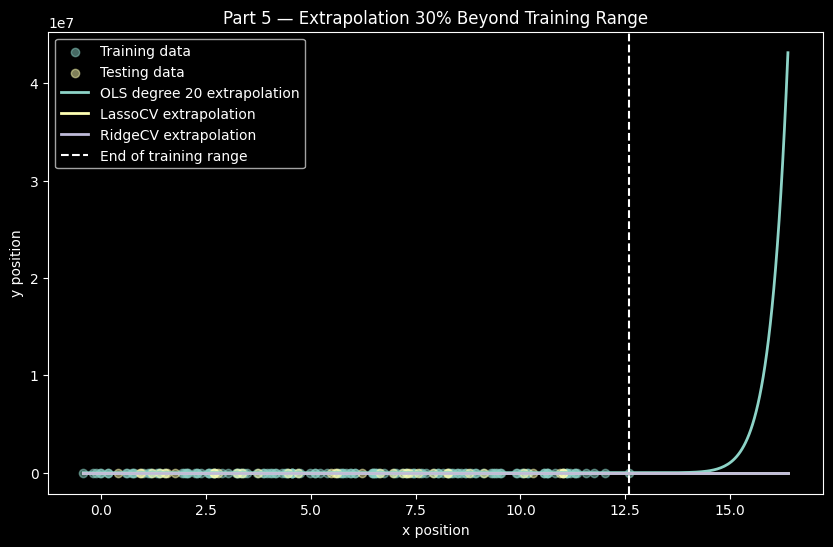

In [13]:
# VERSION Selim

x_extra = np.linspace(min(x_train), 1.3 * max(x_train), 400).reshape(-1, 1)

A_extra_20 = poly20.transform(x_extra)
A_extra_20_scaled = scaler_A20.transform(A_extra_20)

y_extra_OLS20 = scaler_y20.inverse_transform(
    OLS_20.predict(A_extra_20_scaled).reshape(-1, 1)
).ravel()

y_extra_lassoCV = scaler_y20.inverse_transform(
    lasso_cv.predict(A_extra_20_scaled).reshape(-1, 1)
).ravel()

y_extra_ridgeCV = scaler_y20.inverse_transform(
    ridge_cv.predict(A_extra_20_scaled).reshape(-1, 1)
).ravel()

plt.figure(figsize=(10, 6))
plt.scatter(x_train, y_train, alpha=0.5, label="Training data")
plt.scatter(x_test, y_test, alpha=0.5, label="Testing data")

plt.plot(x_extra, y_extra_OLS20, label="OLS degree 20 extrapolation", linewidth=2)
plt.plot(x_extra, y_extra_lassoCV, label="LassoCV extrapolation", linewidth=2)
plt.plot(x_extra, y_extra_ridgeCV, label="RidgeCV extrapolation", linewidth=2)

plt.axvline(max(x_train), linestyle="--", label="End of training range")

plt.xlabel("x position")
plt.ylabel("y position")
plt.title("Part 5 — Extrapolation 30% Beyond Training Range")
plt.legend()
plt.show()